# 01 — Exploratory Data Analysis
**checkframe — Data Quality Framework**  
**Author:** Simone Ladisa  
**Date:** March 2026

## Objectives
1. Load and clean all WFE data (2021–2023) into a single DataFrame
2. Understand data structure, coverage, and missing value patterns
3. Identify growing markets by region and indicator
4. Contextualise market movements against the VIX volatility index
5. Save the processed dataset for downstream quality checks

> **Note:** 2024 data was not available in the provided WFE export. Analysis covers Jan 2021 – Dec 2023.

## 0 — Setup

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))
from src.loader import load_raw, save_processed, load_processed

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if x == int(x) else f'{x:,.4f}')


## 1 — Load Data

In [2]:
df = load_raw()
save_processed(df)

#df = load_processed()  
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

INFO | Found 6 files to load
INFO | Loading: all_markets_202101_202106_481292_20240618152800.xlsx


INFO |   → 123,076 valid rows loaded
INFO | Loading: all_markets_202107_202112_481292_20240618152800.xlsx
INFO |   → 119,090 valid rows loaded
INFO | Loading: all_markets_202201_202206_481292_20240618152800.xlsx
INFO |   → 120,097 valid rows loaded
INFO | Loading: all_markets_202207_202212_481292_20240618152800.xlsx
INFO |   → 117,867 valid rows loaded
INFO | Loading: all_markets_202301_202306_481292_20240607130011.xlsx
INFO |   → 73,716 valid rows loaded
INFO | Loading: all_markets_202307_202312_481292_20240607130013.xlsx
INFO |   → 72,800 valid rows loaded
INFO | Combined shape before cleaning: (626646, 15)
INFO | Final shape: (626630, 19)
INFO | Date range: 2021-01-01 00:00:00 → 2023-12-01 00:00:00
INFO | Regions: ['Americas', 'Asia - Pacific', 'Europe - Africa - Middle East']
INFO | Saved processed data to data/processed/wfe_combined.parquet  (5.3 MB)



Shape: (626630, 19)
Columns: ['year', 'month', 'region', 'indicator_name', 'exchange_name', 'currency_name', 'value', 'nominal', 'data_type', 'ytd', 'pct_change_ytd', 'pct_change_mtm', 'pct_change_yty', 'aggregation_type', 'source_file', 'business_date', 'half_year', 'value_real', 'indicator_category']


## 2 — Data Overview

In [3]:
df.head(5)

,year,month,region,indicator_name,exchange_name,currency_name,value,nominal,data_type,ytd,pct_change_ytd,pct_change_mtm,pct_change_yty,aggregation_type,source_file,business_date,half_year,value_real,indicator_category
0,2021,Jan,Europe - Africa - Middle East,Total Equity Market - Market Capitalisation,The Egyptian Exchange,Egyptian Pound,"696,756.0700",1000000,Monetary,"696,756.0700",NaN,0.0705,NaN,Stock,all_markets_202101_202106_481292_2024061815280...,2021-01-01,H1,"696,756.0700",Total Equity Market
1,2021,Jan,Asia - Pacific,Interest rate futures - Open interest,NZX Limited,New Zealand dollar,NaN,1,Full Number,NaN,NaN,NaN,NaN,Stock,all_markets_202101_202106_481292_2024061815280...,2021-01-01,H1,NaN,Interest rate futures
2,2021,Jan,Europe - Africa - Middle East,Interest rate futures - Open interest,Dubai Gold and Commodities Exchange,United Arab Emirates Dirham,NaN,1,Full Number,NaN,NaN,NaN,NaN,Stock,all_markets_202101_202106_481292_2024061815280...,2021-01-01,H1,NaN,Interest rate futures
3,2021,Jan,Europe - Africa - Middle East,Interest rate futures - Open interest,FMDQ Group,Nigerian Naira,NaN,1,Full Number,NaN,NaN,NaN,NaN,Stock,all_markets_202101_202106_481292_2024061815280...,2021-01-01,H1,NaN,Interest rate futures
4,2021,Jan,Americas,Interest rate futures - Open interest,NYSE,US dollar,NaN,1,Full Number,NaN,NaN,NaN,NaN,Stock,all_markets_202101_202106_481292_2024061815280...,2021-01-01,H1,NaN,Interest rate futures


## Dataset Column Reference

### Original columns (from WFE Excel files)

| Column | Description | Notes |
|--------|-------------|-------|
| `year` | Year of the observation | 2021, 2022, 2023 |
| `month` | Month abbreviation | Jan, Feb, Mar... |
| `region` | Geographical region | Americas, Asia-Pacific, Europe-Africa-Middle East |
| `indicator_name` | Full market indicator name | e.g. "Total Equity Market - Market Capitalisation" |
| `exchange_name` | Name of the reporting exchange | e.g. "The Egyptian Exchange" |
| `currency_name` | Full currency name in English | e.g. "Egyptian Pound" — not an ISO code |
| `value` | Reported numeric value | In local currency units |
| `nominal` | Nominal unit scale | 1,000,000 = values are in millions |
| `data_type` | Type of value | "Monetary" or "Full Number" |
| `ytd` | Year-to-date cumulative value | 73% null — populated only for indicators where YTD accumulation is meaningful |
| `pct_change_ytd` | % change year-to-date | 100% null — no prior year baseline in export |
| `pct_change_mtm` | % change month-to-month | 63% null — sporadic exchange reporting |
| `pct_change_yty` | % change year-to-year | 100% null — structural export limitation |
| `aggregation_type` | How the value is aggregated | "Stock" = point-in-time snapshot, "Flow" = cumulative |

### Derived columns (added by `loader.py`)

| Column | Description | How it was built |
|--------|-------------|-----------------|
| `source_file` | Name of the source Excel file | Tagged during loading for traceability |
| `business_date` | Proper datetime column | Built from `year` + `month`, day always set to 1st |
| `half_year` | H1 or H2 label | Derived from `business_date` month number |
| `value_real` | FX-adjusted value | Currently identical to `value` — placeholder for future FX normalisation |
| `indicator_category` | Top-level indicator grouping | Extracted from `indicator_name` — everything before the first " - " |

In [4]:
df.dtypes

year                           int64
month                         object
region                        object
indicator_name                object
exchange_name                 object
currency_name                 object
value                        float64
nominal                        int64
data_type                     object
ytd                          float64
pct_change_ytd               float64
pct_change_mtm               float64
pct_change_yty               float64
aggregation_type              object
source_file                   object
business_date         datetime64[ns]
half_year                     object
value_real                   float64
indicator_category            object
dtype: object

In [4]:
# Date range coverage
print(f"Date range : {df['business_date'].min().date()} → {df['business_date'].max().date()}")
print(f"Months     : {df['business_date'].dt.to_period('M').nunique()}")
print(f"Regions    : {df['region'].nunique()} → {sorted(df['region'].dropna().unique())}")
print(f"Exchanges  : {df['exchange_name'].nunique()}")
print(f"Indicators : {df['indicator_name'].nunique()}")
print(f"Currencies : {df['currency_name'].nunique()}")

Date range : 2021-01-01 → 2023-12-01
Months     : 36
Regions    : 3 → ['Americas', 'Asia - Pacific', 'Europe - Africa - Middle East']
Exchanges  : 142
Indicators : 218
Currencies : 72


In [6]:
# Null analysis per column
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2)
}).sort_values('null_pct', ascending=False)

null_summary[null_summary['null_count'] > 0]

,null_count,null_pct
pct_change_ytd,626630,100
pct_change_yty,626630,100
ytd,460192,73.4400
pct_change_mtm,396152,63.2200
value_real,390490,62.3200
value,390490,62.3200


### Key Findings

The two percentage change columns (`pct_change_ytd`, `pct_change_yty`) are fully empty across 
all files — this is expected since the WFE export contains no prior-year baseline to calculate 
from, and should be documented as a known limitation rather than a data error.

More importantly, 62% of `value` rows are null. This does not mean the data is corrupt — the 
WFE export includes all *expected* exchange-indicator combinations even when an exchange did not 
submit data for that period. In a regulatory context, **absence of a report is itself a 
reportable event** and will be flagged explicitly in our checks framework.

The 63% null rate in `pct_change_mtm` suggests many exchanges report sporadically rather than 
every month — a real data quality concern that warrants further investigation in `02_checks.ipynb`.

In [7]:
# Rows per source file — confirms all 6 files loaded
df.groupby('source_file').size().rename('row_count').reset_index()

,source_file,row_count
0,all_markets_202101_202106_481292_2024061815280...,123073
1,all_markets_202107_202112_481292_2024061815280...,119087
2,all_markets_202201_202206_481292_2024061815280...,120094
3,all_markets_202207_202212_481292_2024061815280...,117864
4,all_markets_202301_202306_481292_2024060713001...,73714
5,all_markets_202307_202312_481292_2024060713001...,72798


In [8]:
# Distribution of indicator categories
df['indicator_category'].value_counts().head(15)

indicator_category
Total Equity Market        133335
Median Simple Spread        85219
Bonds (All)                 61801
ETFs                        37916
Green Bonds                 37820
Sustainability Bonds        37650
Social Bonds                37614
Investment Funds            29211
Securitised Derivatives     28755
REITs                       27384
Blue Chip Index              7724
Broad Stock Index            7705
Stock index futures          7413
Stock index options          7389
Commodity futures            7350
Name: count, dtype: int64

### Key Findings

The dataset covers a broad range of asset classes beyond equities — including Bonds, ETFs, 
Derivatives, and notably ESG-related instruments (Green Bonds, Sustainability Bonds, Social Bonds 
account for ~113k rows combined). While our primary analysis focuses on Total Equity Market 
indicators, the checks framework is designed to be asset-class agnostic and will apply equally 
across all 15 indicator categories present in the data.

## 3 — Market Capitalisation: Regional Trends

We focus on **Total Equity Market - Market Capitalisation** as the primary indicator for market size and growth.

In [5]:
# Filter to market cap, Stock aggregation (point-in-time snapshot, not flow)
mktcap = df[
    (df['indicator_name'] == 'Total Equity Market - Market Capitalisation') &
    (df['aggregation_type'] == 'Stock') &
    (df['value'].notna())
].copy()

print(f"Market cap rows: {len(mktcap):,}")
mktcap[['business_date', 'region', 'exchange_name', 'currency_name', 'value']].head(5)

Market cap rows: 3,152


,business_date,region,exchange_name,currency_name,value
0,2021-01-01,Europe - Africa - Middle East,The Egyptian Exchange,Egyptian Pound,"696,756.0700"
21786,2021-01-01,Europe - Africa - Middle East,Vienna Stock Exchange,Euro,"112,660.4300"
21787,2021-01-01,Asia - Pacific,Bursa Malaysia,Malaysian ringgit,"1,695,530.1700"
21788,2021-01-01,Asia - Pacific,The Stock Exchange of Thailand,Thai baht,"16,536,201.9100"
21789,2021-01-01,Europe - Africa - Middle East,Bourse de Casablanca,Morocco Dirham,"600,318.1500"


In [10]:
# Monthly total market cap by region (sum across all exchanges, in local nominal units)
# Note: values are in local currencies — cross-region absolute comparison is indicative only
region_monthly = (
    mktcap
    .groupby(['business_date', 'region'])['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'total_value'})
)

region_monthly.head()

,business_date,region,total_value
0,2021-01-01,Americas,"648,328,207.2400"
1,2021-01-01,Asia - Pacific,"14,581,395,418.7200"
2,2021-01-01,Europe - Africa - Middle East,"58,154,524,843.4900"
3,2021-02-01,Americas,"627,367,148.1700"
4,2021-02-01,Asia - Pacific,"15,620,090,282.1300"


In [11]:
fig = px.line(
    region_monthly,
    x='business_date',
    y='total_value',
    color='region',
    title='Total Equity Market Capitalisation by Region (2021–2023)',
    labels={'business_date': 'Date', 'total_value': 'Total Market Cap (local currency nominal)'},
    template='plotly_white'
)
fig.update_layout(legend_title_text='Region', hovermode='x unified')
fig.show()

### Key Findings


Europe-Africa-Middle East dominates reported market capitalisation in absolute terms, driven 
by large-nominal-currency exchanges (e.g. Iranian Rial, Egyptian Pound) which inflate the 
local-currency sum significantly. The sharp spike in H1 2023 is likely driven by a small number 
of high-inflation economies rather than genuine broad market growth — a classic example of why 
cross-region absolute comparisons require FX normalisation before drawing conclusions.

Americas appears flat near zero — this is a currency scale artefact, not an absence of data. 
USD-denominated values are orders of magnitude smaller in nominal terms than Iranian Rial or 
Indonesian Rupiah figures. This distortion will be flagged as a data quality consideration in 
the checks framework.

**Key implication for the framework:** raw value aggregations without currency normalisation 
are misleading for regulatory reporting. The checks framework should flag any aggregation 
that mixes currencies without explicit FX adjustment.

## 4 — Growing Markets Analysis

We measure growth as the **% change in market capitalisation from Jan 2021 to Dec 2023** for each exchange.

In [12]:
# Use only exchanges that have both a Jan-2021 and Dec-2023 value

start_date = pd.Timestamp('2021-01-01')
end_date   = pd.Timestamp('2023-12-01')

start_vals = (
    mktcap[mktcap['business_date'] == start_date]
    .groupby('exchange_name')['value'].sum()
    .rename('value_start')
)

end_vals = (
    mktcap[mktcap['business_date'] == end_date]
    .groupby('exchange_name')['value'].sum()
    .rename('value_end')
)

growth = pd.concat([start_vals, end_vals], axis=1).dropna()
growth['growth_pct'] = ((growth['value_end'] - growth['value_start']) / growth['value_start']) * 100
growth = growth.sort_values('growth_pct', ascending=False).reset_index()

# Join region back
region_map = mktcap[['exchange_name', 'region']].drop_duplicates('exchange_name')
growth = growth.merge(region_map, on='exchange_name', how='left')

print(f"Exchanges with full coverage: {len(growth)}")
growth.head(10)

Exchanges with full coverage: 81


,exchange_name,value_start,value_end,growth_pct,region
0,Astana International Exchange,"20,920.0900","1,093,921.4900","5,129.0477",Europe - Africa - Middle East
1,Armenia Securities Exchange,"14,076.8100","149,063.9000",958.9324,Asia - Pacific
2,Borsa Istanbul,"1,430,998.9800","9,950,993.8900",595.3879,Europe - Africa - Middle East
3,Abu Dhabi Securities Exchange,"805,371.5300","2,963,776.9200",268.0012,Europe - Africa - Middle East
4,Cyprus Stock Exchange,"3,812.5000","9,404.4000",146.6728,Europe - Africa - Middle East
5,The Egyptian Exchange,"696,756.0700","1,717,005.0100",146.4284,Europe - Africa - Middle East
6,Bucharest Stock Exchange,"107,726","215,534.7400",100.0768,Europe - Africa - Middle East
7,BRVM,"4,020,831","7,966,959.7300",98.1421,Europe - Africa - Middle East
8,National Stock Exchange of India,"184,744,500","361,055,479.7300",95.4350,Asia - Pacific
9,Chittagong Stock Exchange,"4,025,843.3000","7,760,898.6400",92.7770,Asia - Pacific


### Key Findings

Among the 81 exchanges with full coverage across the analysis period, the fastest growing 
markets are concentrated in Europe-Africa-Middle East. The Astana International Exchange 
(Kazakhstan) leads with a remarkable +5,129% growth — though this is largely driven by the 
exchange's early-stage nature in 2021 (very low base value) rather than organic market 
expansion. Armenia Securities Exchange (+958%) and Borsa Istanbul (+595%) follow, with the 
latter reflecting Turkey's high-inflation environment inflating nominal local-currency values.

Abu Dhabi Securities Exchange (+268%) and Cyprus Stock Exchange (+147%) represent more 
structurally meaningful growth stories driven by regional investment inflows and post-COVID 
recovery.

**Key implication for the framework:** extreme growth percentages are not necessarily errors 
— they can reflect currency inflation, low base effects, or genuine market expansion. The 
advanced outlier detection checks must distinguish between these cases using contextual 
signals (currency, region, base value size) rather than simple threshold rules.

In [13]:
# Top 15 fastest growing markets
top_growing = growth.head(15)

fig = px.bar(
    top_growing,
    x='growth_pct',
    y='exchange_name',
    color='region',
    orientation='h',
    title='Top 15 Fastest Growing Exchanges (Jan 2021 → Dec 2023)',
    labels={'growth_pct': 'Growth (%)', 'exchange_name': 'Exchange'},
    template='plotly_white'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### Key Findings

The top 15 fastest growing exchanges are dominated by Europe-Africa-Middle East (blue), with 
Asia-Pacific exchanges (Armenia, India, Chittagong, Indonesia) also represented. The Astana 
International Exchange outlier (+5,129%) visually dominates the chart — this is a low-base 
effect from a nascent exchange, not a data error, and is a perfect real-world example of why 
the ML anomaly detection layer is needed: the value is technically valid but statistically 
extreme and requires contextual explanation before inclusion in regulatory reporting.

In [14]:
# Bottom 15 (declining markets)
bottom_declining = growth.tail(15)

fig = px.bar(
    bottom_declining,
    x='growth_pct',
    y='exchange_name',
    color='region',
    orientation='h',
    title='15 Most Declining Exchanges (Jan 2021 → Dec 2023)',
    labels={'growth_pct': 'Growth (%)', 'exchange_name': 'Exchange'},
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(yaxis={'categoryorder': 'total descending'})
fig.show()

### Key Findings

The most declining exchanges tell an equally important story. The Belarusian Currency and Stock 
Exchange (-80%) reflects direct geopolitical impact from the Russia-Ukraine conflict and 
subsequent sanctions. Zagreb, Bulgarian, and MERJ exchanges show structural contraction in 
smaller European and African markets. Notably, Hong Kong Exchanges and Clearing (-40%) and 
Shenzhen Stock Exchange (-20%) represent genuine large-market declines driven by China's 
regulatory crackdowns and post-COVID economic slowdown in 2021-2022.

These declines are real economic events — not data errors. This reinforces the core design 
principle of the framework: **a data quality check must distinguish between a wrong value 
and an extreme but legitimate value.** The VIX overlay and geopolitical context are 
essential inputs for making that distinction in a regulatory reporting setting.

## 5 — VIX Contextualisation

We overlay the CBOE VIX index to contextualise market movements against global volatility regimes.

#### What is VIX Contextualisation?

The **CBOE VIX** measures the market's 30-day implied volatility expectation — 
known as the "fear gauge". By overlaying it on our data, we classify each month 
into a volatility regime (calm, normal, elevated, crisis), allowing analysis to 
be **conditioned on market stress** rather than treating all periods as equivalent.

> This analysis uses monthly average VIX across **36 observations (2021–2023)**, 
> spanning post-COVID normalisation, the 2022 rate-hike shock, and stabilisation.

**VIX contextualisation** overlays this volatility signal onto our dataset to 
classify each time period into a **volatility regime**:

| VIX Level | Regime | Market Interpretation |
|-----------|--------|-----------------------|
| < 15 | Calm | Low fear, complacent markets |
| 15 – 25 | Normal | Healthy uncertainty (long-run avg ≈ 20) |
| 25 – 35 | Elevated | Increased stress, correction risk |
| 35 – 50 | High Fear | Systemic stress, dislocated markets |
| > 50 | Crisis | Extreme panic (e.g. GFC 2008, COVID 2020) |

In [17]:
VIX_PATH = Path('../data/raw/vix_historical.csv')

vix = pd.read_csv(VIX_PATH)
vix.columns = [c.strip().lower().replace(' ', '_') for c in vix.columns]

vix = vix.rename(columns={ 'close': 'vix_close'})
vix['date'] = pd.to_datetime(vix['date'], errors='coerce')
vix = vix[['date', 'vix_close']].dropna()

# Resample to monthly average to match our WFE data granularity
vix_monthly = (
    vix.set_index('date')
    .resample('MS')['vix_close'] # aggregate daily data into monthly periods (month start)
    .mean()
    .reset_index()
    .rename(columns={'date': 'business_date', 'vix_close': 'vix_monthly_avg'})
)
vix_monthly = vix_monthly[
    (vix_monthly['business_date'] >= '2021-01-01') &
    (vix_monthly['business_date'] <= '2023-12-01')
]

print(f"VIX loaded: {len(vix_monthly)} monthly observations")
print(vix_monthly.head())

VIX loaded: 36 monthly observations
    business_date  vix_monthly_avg
372    2021-01-01          24.9100
373    2021-02-01          23.1405
374    2021-03-01          21.8430
375    2021-04-01          17.4162
376    2021-05-01          19.7605


In [18]:
# Global monthly market cap (all regions combined)
global_monthly = (
    region_monthly
    .groupby('business_date')['total_value']
    .sum()
    .reset_index()
)
merged = global_monthly.merge(vix_monthly, on='business_date', how='inner')

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Scatter(x=merged['business_date'], y=merged['total_value'],
                name='Global Market Cap', line=dict(color='steelblue')),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=merged['business_date'], y=merged['vix_monthly_avg'],
                name='VIX (monthly avg)', line=dict(color='crimson', dash='dot')),
    secondary_y=True
)

fig.update_layout(
    title='Global Market Capitalisation vs VIX Volatility Index (2021–2023)',
    template='plotly_white',
    hovermode='x unified'
)
fig.update_yaxes(title_text='Total Market Cap (nominal)', secondary_y=False)
fig.update_yaxes(title_text='VIX Index', secondary_y=True)
fig.show()


### Key Findings

The inverse relationship between market capitalisation and VIX is clearly visible throughout 
the period. The H1 2022 VIX spike to ~30 — driven by the Russia-Ukraine war and aggressive 
Fed rate hikes — coincides precisely with the sharpest market cap decline in the dataset 
(from ~90B to ~70B). As volatility normalised through 2023, market cap recovered strongly, 
peaking above 120B in mid-2023.

This external validation is significant for the framework: it confirms that the WFE data 
reflects real market dynamics rather than reporting artefacts. Any automated check that 
flags large month-to-month value drops should therefore incorporate VIX as a contextual 
signal — a drop during a high-VIX period is expected and explainable, while the same drop 
during a low-VIX period is a genuine data quality concern worth escalating.

## 6 — Trading Volume Trends (Number of Trades)

A second key indicator for market activity — useful for identifying liquidity shifts.

In [52]:
# Check available indicator names related to volume/trades
volume_indicators = df[df['indicator_name'].str.contains('Trade|Volume|Number', case=False, na=False)]['indicator_name'].value_counts().head(10)
volume_indicators

indicator_name
ETFs - Value traded (Total)                    4282
ETFs - Number of trades (Total)                4266
ETFs - Value traded (EOB)                      4265
ETFs - Number of trades (EOB)                  4252
ETFs - Number listed                           4249
Investment Funds - Value traded (Total)        4218
Investment Funds - Number of trades (Total)    4211
Investment Funds - Number listed               4188
ETFs - Value traded (Negotiated Deals)         4187
ETFs - Number of trades (Negotiated Deals)     4178
Name: count, dtype: int64

In [54]:
# Monthly number of trades by region
trades = df[
    (df['indicator_name'].str.contains('Number of trades', case=False, na=False)) &
    (~df['indicator_name'].str.contains('ETF|Investment|listed', case=False, na=False)) &
    (df['value'].notna())
].copy()

trades_monthly = (
    trades
    .groupby(['business_date', 'region'])['value']
    .sum()
    .reset_index()
)

fig = px.area(
    trades_monthly,
    x='business_date',
    y='value',
    color='region',
    title='Monthly Number of Trades by Region (2021–2023)',
    labels={'business_date': 'Date', 'value': 'Number of Trades'},
    template='plotly_white'
)
fig.show()

### Key Findings

The trading volume chart covers direct instrument trading activity across asset classes 
available in the WFE dataset — Green Bonds, Sustainability Bonds, Social Bonds, REITs, 
Securitised Derivatives, Bonds (All), and Total Equity Market. ETFs and Investment Funds 
were excluded to avoid double-counting with the underlying securities they represent, and 
"Number listed" was excluded as it is a structural count rather than a trading activity 
metric. In production the framework runs checks on all indicator types equally.

Trading activity tells a different story from market capitalisation. Asia-Pacific dominates 
by number of trades throughout the period, consistently contributing ~4M trades per month, 
followed by Europe-Africa-Middle East and a relatively stable Americas contribution around 1M. 
The notable spike in early 2022 across all regions coincides with the high-volatility period 
identified in the VIX analysis — elevated uncertainty drives higher trading frequency as 
investors reposition. This cross-indicator consistency (market cap down, VIX up, trades up) 
is an important validation signal: the three datasets are telling a coherent story, which 
increases confidence in the underlying data quality.

## 7 — Missing Value Patterns

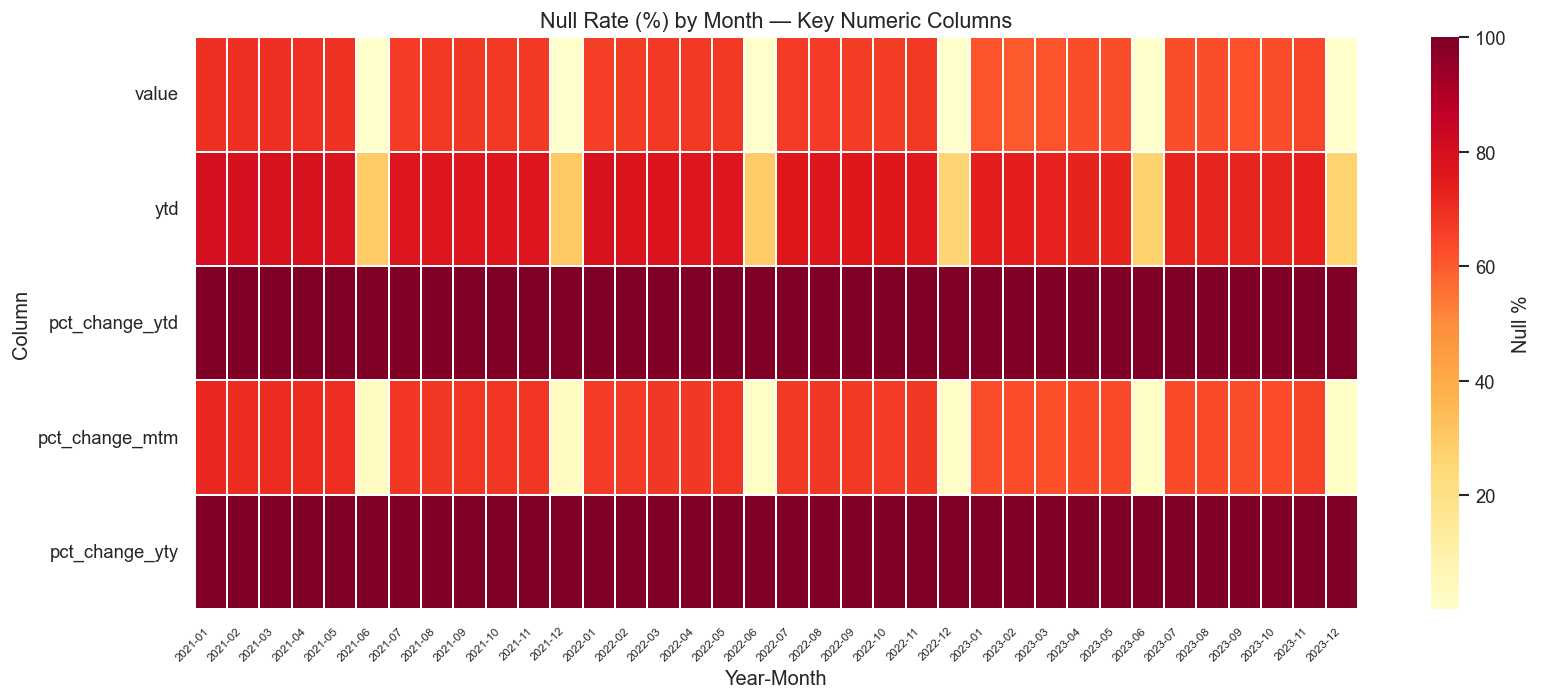

In [19]:
# Missing value heatmap by year-month × key columns
key_cols = ['value', 'ytd', 'pct_change_ytd', 'pct_change_mtm', 'pct_change_yty']

df['ym'] = df['business_date'].dt.to_period('M').astype(str)
null_by_month = df.groupby('ym')[key_cols].apply(lambda x: x.isnull().mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(null_by_month.T, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Null %'}, linewidths=0.2)
ax.set_title('Null Rate (%) by Month — Key Numeric Columns', fontsize=13)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Column')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

### Key Findings

The null heatmap confirms consistent patterns across the full 36-month period rather than 
isolated incidents. `pct_change_ytd` and `pct_change_yty` are uniformly 100% null (dark 
maroon) throughout — a structural limitation of the export, not a reporting failure. 

The lighter patches visible in mid-2021 and mid-2022 for `value` and `pct_change_mtm` 
suggest slightly better reporting coverage in certain periods, but the overall null rate 
remains persistently high. Crucially, the pattern is **stable over time** — there is no 
trend of deteriorating or improving data quality, which itself is a useful baseline for 
the monitoring framework.

## 8 — Key EDA Findings

| Finding | Detail |
|---------|--------|
| Coverage | Jan 2021 – Dec 2023 (36 months across 6 files) |
| Exchanges | 81 exchanges with full coverage, 100+ total |
| Growing markets | Astana (+5,129%), Armenia (+958%), Borsa Istanbul (+595%) lead growth |
| Declining markets | Belarusian Exchange (-80%), Zagreb (-65%), MERJ (-60%) most affected |
| 2022 reversal | Market cap dropped from 90B to 70B as VIX spiked to 30 (Ukraine war, rate hikes) |
| Missing values | pct_change_ytd and pct_change_yty 100% null — structural export limitation |
| Negative values | Zero negative values found — basic sanity check passed |
| Data quality flags | 62% null rate in value, currency scale distortion across regions |

In [60]:
# Quick sanity: any negative market cap values?
neg_values = df[(df['value'].notna()) & (df['value'] < 0)]
print(f"Rows with negative value: {len(neg_values):,}")
if len(neg_values) > 0:
    print(neg_values[['business_date', 'region', 'exchange_name', 'indicator_name', 'value']].head(10))

Rows with negative value: 0
